In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as mticker


paths = {
    "ALA": Path("ALA.csv"),
    "iNaturalist": Path("iNaturalist.csv"),
    "Prototype": Path("Prototype.csv"),
}

out_dir = Path("experiment0_outputs")
out_dir.mkdir(exist_ok=True, parents=True)

In [2]:
def count_decimals(value):
    """Count decimal places of a stringified number, preserving trailing zeros."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if len(s) >= 2 and s[0] == s[-1] == '"':
        s = s[1:-1]
    if "." in s:
        frac = s.split(".")[1]
        frac = "".join([c for c in frac if c.isdigit()])
        return len(frac)
    return 0

def find_col(df, candidates):
    """Find a column name in df from a list of candidates (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def parse_year_from_date(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    # Try common formats
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y", "%Y/%m/%d", "%d-%m-%Y", "%Y"):
        try:
            dt = datetime.strptime(s[:10], fmt)
            return dt.year
        except:
            continue
    # fallback: regex find first 4-digit year
    import re
    m = re.search(r"(19|20)\d{2}", s)
    return int(m.group()) if m else np.nan

def tier_from_decimals(d):
    if pd.isna(d):
        return "unknown"
    d = int(d)
    if d <= 1: return "≈10–100 km (0–1 dp)"
    if d == 2: return "≈1–10 km (2 dp)"
    if d == 3: return "≈100–1000 m (3 dp)"
    if d == 4: return "≈10–100 m (4 dp)"
    if d == 5: return "≈1–10 m (5 dp)"
    if d >= 6: return "<1 m (6+ dp)"
    return "unknown"


In [3]:
loaded = {}
issues = []

for name, path in paths.items():
    try:
        df = pd.read_csv(path, dtype=str, low_memory=False)
        df["__source"] = name
        loaded[name] = df
    except FileNotFoundError:
        issues.append(f"{name} not found at {path}")
    except Exception as e:
        issues.append(f"Failed to read {name}: {e}")

if issues:
    print("\n".join(["[READ ISSUE] " + m for m in issues]))

if not loaded:
    raise RuntimeError("No CSVs could be loaded. Check file paths.")
    
df_all = pd.concat(loaded.values(), ignore_index=True)
print(f"Loaded rows: {len(df_all):,}")

df_all = pd.concat(loaded.values(), ignore_index=True)
print(f"合并后总行数: {len(df_all):,}")

df_all_raw = df_all.copy()

full_dups = df_all.duplicated().sum()
print(f"完全重复的行数: {full_dups:,}")
df_all_nofull = df_all.drop_duplicates()


key_cols = ["Scientific Name", "Decimal Latitude", "Decimal Longitude", "Event Date"]
missing = [c for c in key_cols if c not in df_all_nofull.columns]

if not missing:
    key_dups = df_all_nofull.duplicated(subset=key_cols).sum()
    print(f"关键字段重复的行数（{key_cols}）: {key_dups:,}")
    df_all = df_all_nofull.drop_duplicates(subset=key_cols).reset_index(drop=True)
    print(f"关键字段去重后剩余行数: {len(df_all):,}")
else:
    print(f"跳过关键字段去重，缺少列: {missing}")
    df_all = df_all_nofull.reset_index(drop=True)

total = len(df_all_raw)
print(f"完全重复占比: {full_dups/total:.2%}")
if not missing:
    print(f"关键字段重复占比: {key_dups/len(df_all_nofull):.2%}")

df_all.head(3)


Loaded rows: 36,444
合并后总行数: 36,444
完全重复的行数: 0
关键字段重复的行数（['Scientific Name', 'Decimal Latitude', 'Decimal Longitude', 'Event Date']）: 4,923
关键字段去重后剩余行数: 31,521
完全重复占比: 0.00%
关键字段重复占比: 13.51%


,Occurrence ID,Scientific Name,Event Date,Dataset Name,Reserve Name,Decimal Latitude,Decimal Longitude,Individual Count,Reproductive Condition,Establishment Means,...,Locality,Location Remarks,Identified By,Date Identified,Owner Institution Code,Basis of Record,Data Generalizations,Recorded By,Client Business Name,__source
0,35072,Acacia binervia,2011-04-13T00:00:00,ACA Vegetation Survey,Deepwater,-33.950045,150.973523,NaN,NaN,NaN,...,locality withheld,locationRemarks withheld,NaN,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,OEMM09100802;OEMM09100803;OJJS10080400;OIXR131...,CB Council,ALA
1,25664,Acacia decurrens,2007-04-16T00:00:00,ACA Vegetation Survey,Deepwater,-33.94951,150.973882,NaN,NaN,NaN,...,locality withheld,locationRemarks withheld,NaN,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,ODMP05122005;OEMM09100802;OPUR23021400,CB Council,ALA
2,20237,Acacia decurrens,2007-04-16T00:00:00,ACA Vegetation Survey,Deepwater,-33.948971,150.973462,NaN,NaN,NaN,...,locality withheld,locationRemarks withheld,NaN,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,ODMP05122005;OEMM09100802;OPUR23021400,CB Council,ALA


In [8]:
lat_col = find_col(df_all, ["latitude", "lat", "decimalLatitude", "decimal latitude"])
lon_col = find_col(df_all, ["longitude", "lon", "decimalLongitude", "decimal longitude"])
date_col = find_col(df_all, ["date", "eventDate", "event date", "observationDate", "observed_on"])
year_col = find_col(df_all, ["year", "Year"])


# Derive year
if year_col is None:
    if date_col is not None:
        df_all["year"] = df_all[date_col].apply(parse_year_from_date)
    else:
        df_all["year"] = np.nan
else:
    df_all["year"] = pd.to_numeric(df_all[year_col], errors="coerce")

# Compute decimals from lat/lon (use max of the two for conservative precision)
if lat_col is not None and lon_col is not None:
    dec_lat = df_all[lat_col].apply(count_decimals)
    dec_lon = df_all[lon_col].apply(count_decimals)
    df_all["decimals"] = pd.concat([dec_lat, dec_lon], axis=1).max(axis=1)
else:
    df_all["decimals"] = np.nan

df_clean = df_all.dropna(subset=["year", "decimals"]).copy()
df_clean["year"] = df_clean["year"].astype(int)
df_clean["decimals"] = df_clean["decimals"].astype(int)
df_clean["precision_tier"] = df_clean["decimals"].apply(tier_from_decimals)

print(f"Usable rows (with year & decimals): {len(df_clean):,}")
df_clean.head(5)


Usable rows (with year & decimals): 31,521


,Occurrence ID,Scientific Name,Event Date,Dataset Name,Reserve Name,Decimal Latitude,Decimal Longitude,Individual Count,Reproductive Condition,Establishment Means,...,Date Identified,Owner Institution Code,Basis of Record,Data Generalizations,Recorded By,Client Business Name,__source,decimals,year,precision_tier
0,35072,Acacia binervia,2011-04-13T00:00:00,ACA Vegetation Survey,Deepwater,-33.950045,150.973523,NaN,NaN,NaN,...,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,OEMM09100802;OEMM09100803;OJJS10080400;OIXR131...,CB Council,ALA,6,2011,<1 m (6+ dp)
1,25664,Acacia decurrens,2007-04-16T00:00:00,ACA Vegetation Survey,Deepwater,-33.94951,150.973882,NaN,NaN,NaN,...,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,ODMP05122005;OEMM09100802;OPUR23021400,CB Council,ALA,6,2007,<1 m (6+ dp)
2,20237,Acacia decurrens,2007-04-16T00:00:00,ACA Vegetation Survey,Deepwater,-33.948971,150.973462,NaN,NaN,NaN,...,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,ODMP05122005;OEMM09100802;OPUR23021400,CB Council,ALA,6,2007,<1 m (6+ dp)
3,32980,Acacia decurrens,2011-04-13T00:00:00,ACA Vegetation Survey,Deepwater,-33.952058,150.980812,NaN,NaN,NaN,...,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,OEMM09100802;OEMM09100803;OJJS10080400;OIXR131...,CB Council,ALA,6,2011,<1 m (6+ dp)
4,34722,Acacia decurrens,2011-04-13T00:00:00,ACA Vegetation Survey,Deepwater,-33.951875,150.979561,NaN,NaN,NaN,...,NaN,Anne Clements & Associates,HUMAN_OBSERVATION,NaN,OEMM09100802;OEMM09100803;OJJS10080400;OIXR131...,CB Council,ALA,6,2011,<1 m (6+ dp)


In [9]:
summary_overall = (
    df_clean.groupby(["__source", "year"])["decimals"]
    .median()
    .reset_index(name="median_decimals")
    .sort_values(["__source", "year"])
)

summary_tier_share = (
    df_clean.groupby(["__source", "precision_tier"])
    .size()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: (s / s.sum()).round(3))
    .reset_index(name="share")
    .sort_values(["__source", "share"], ascending=[True, False])
)

# Save outputs
summary_overall_path = out_dir / "E0_median_decimals_by_year.csv"
summary_tier_path = out_dir / "E0_precision_tier_share.csv"
df_clean_path = out_dir / "E0_clean_records_sample.csv"

summary_overall.to_csv(summary_overall_path, index=False)
summary_tier_share.to_csv(summary_tier_path, index=False)
df_clean.sample(min(1000, len(df_clean))).to_csv(df_clean_path, index=False)

summary_overall.head(10)


,__source,year,median_decimals
0,ALA,1886,7.0
1,ALA,1889,6.0
2,ALA,1892,6.0
3,ALA,1895,7.0
4,ALA,1897,7.0
5,ALA,1901,6.0
6,ALA,1908,6.0
7,ALA,1909,6.0
8,ALA,1910,6.0
9,ALA,1912,6.0


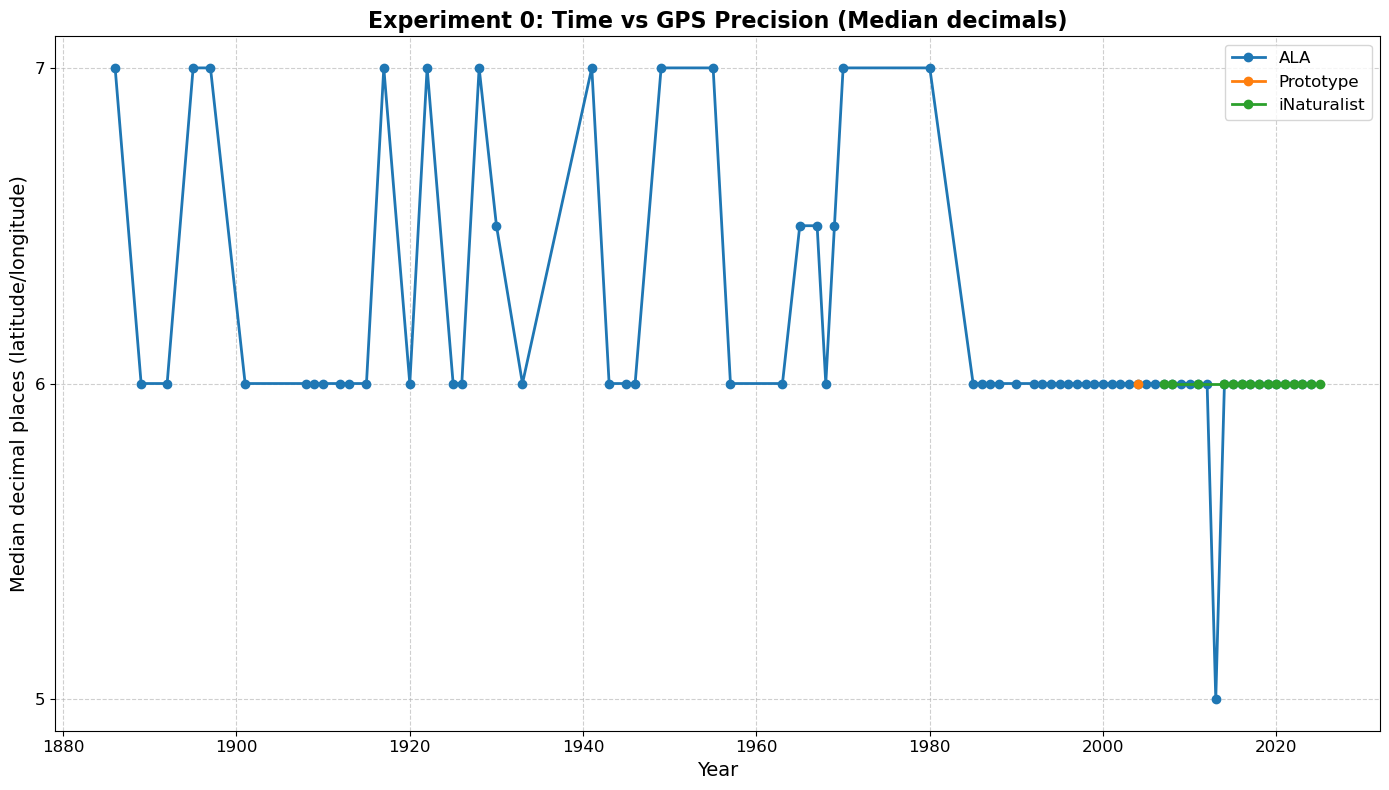

In [10]:
plt.figure(figsize=(14,8))

for src, g in summary_overall.groupby("__source"):
    plt.plot(
        g["year"], g["median_decimals"], 
        marker="o", markersize=6, linewidth=2, label=src
    )


plt.xlabel("Year", fontsize=14)
plt.ylabel("Median decimal places (latitude/longitude)", fontsize=14)
plt.title("Experiment 0: Time vs GPS Precision (Median decimals)", fontsize=16, weight="bold")


plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12, frameon=True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(out_dir / "E0_trend_combined_beautified.png", dpi=300)
plt.show()


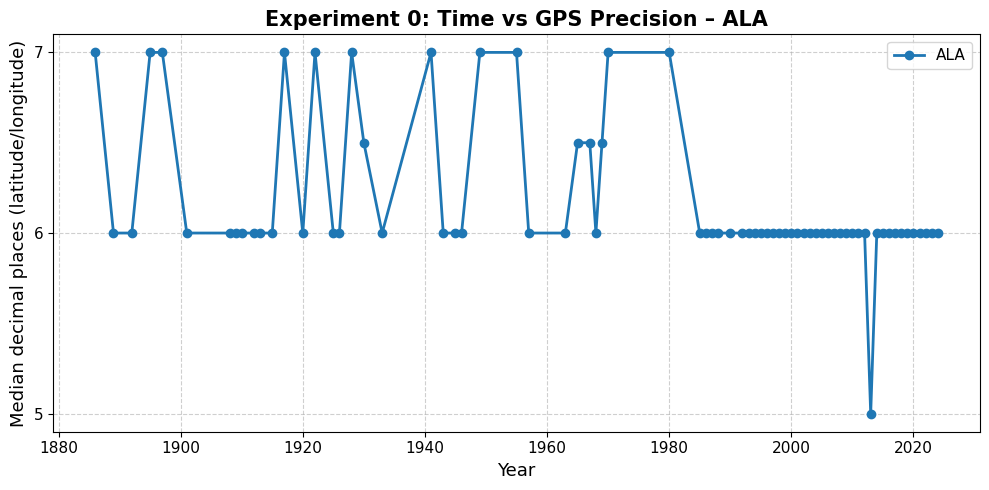

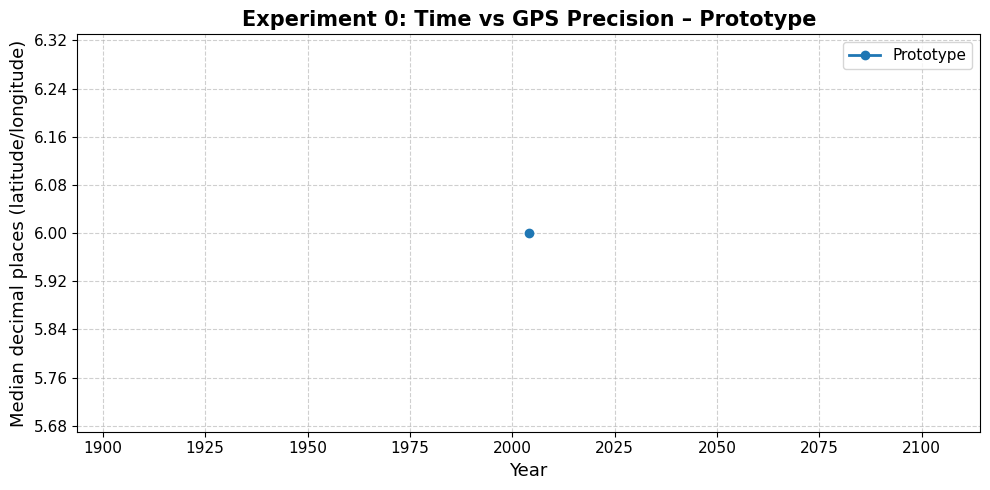

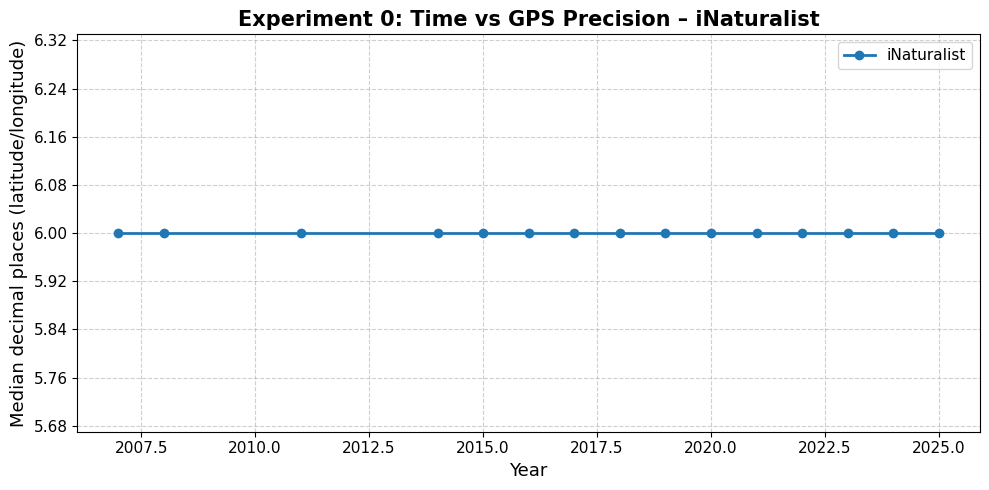

In [11]:
for src, g in summary_overall.groupby("__source"):
    plt.figure(figsize=(10,5))
    plt.plot(
        g["year"], g["median_decimals"], 
        marker="o", markersize=6, linewidth=2, label=src
    )
    
    plt.xlabel("Year", fontsize=13)
    plt.ylabel("Median decimal places (latitude/longitude)", fontsize=13)
    plt.title(f"Experiment 0: Time vs GPS Precision – {src}", fontsize=15, weight="bold")
    

    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    

    plt.legend(fontsize=11, frameon=True)
    
    plt.tight_layout()
    plt.savefig(out_dir / f"E0_trend_{src}_beautified.png", dpi=300)
    plt.show()


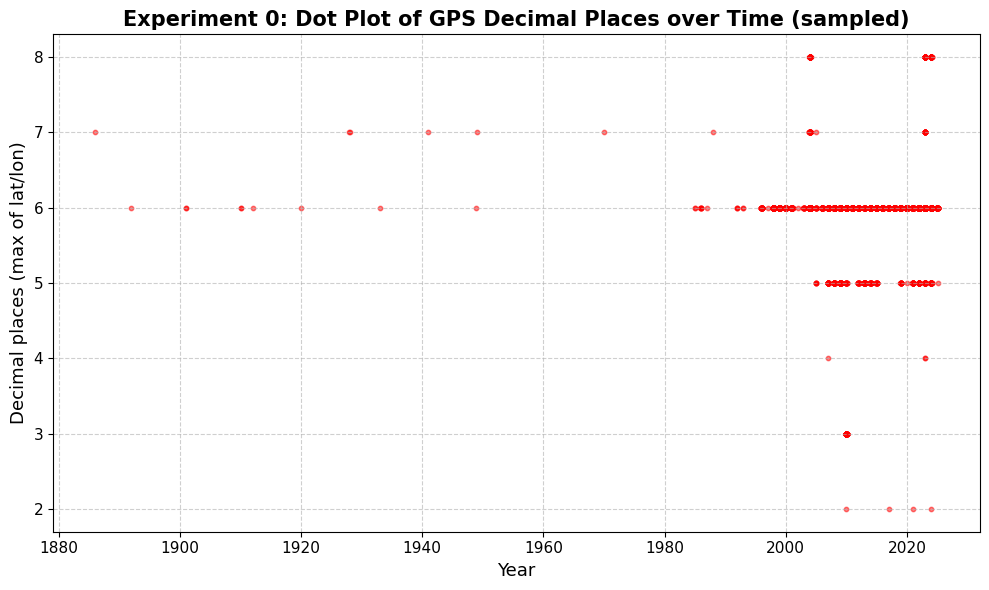

In [12]:
sampled = df_clean.sample(min(10000, len(df_clean)), random_state=42).copy()
rng = np.random.default_rng(42)
sampled["_year_jitter"] = sampled["year"] + rng.normal(0, 0.05, size=len(sampled))

plt.figure(figsize=(10,6))
plt.scatter(
    sampled["_year_jitter"], sampled["decimals"], 
    s=10, alpha=0.5, color="red"
)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Decimal places (max of lat/lon)", fontsize=13)
plt.title("Experiment 0: Dot Plot of GPS Decimal Places over Time (sampled)", fontsize=15, weight="bold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(out_dir / "E0_dotplot_sampled_red.png", dpi=300)
plt.show()


In [13]:


import folium


reserve_keyword = "Lansdowne"   
dot_color       = "#d86b1c"     
circle_color    = "#8fbc8f"     
circle_opacity  = 0.25          
dot_radius      = 3             
max_points      = 5000          


lat_col = "Decimal Latitude"
lon_col = "Decimal Longitude"


df_map = df_clean.copy()
if "Reserve Name" in df_map.columns:
    df_map = df_map[df_map["Reserve Name"].str.contains(reserve_keyword, case=False, na=False)]


df_map = df_map.dropna(subset=[lat_col, lon_col]).copy()
if len(df_map) > max_points:
    df_map = df_map.sample(max_points, random_state=42)


center_lat = df_map[lat_col].astype(float).median()
center_lon = df_map[lon_col].astype(float).median()


lat_km = 111.0
lon_km = 111.0 * np.cos(np.deg2rad(center_lat))
d_km = np.sqrt(
    ((df_map[lat_col].astype(float) - center_lat) * lat_km) ** 2 +
    ((df_map[lon_col].astype(float) - center_lon) * lon_km) ** 2
)
radius_m = float(np.percentile(d_km, 95) * 2 * 1000)  # 95分位 * 2 倍，转米
radius_m = max(radius_m, 500) 


m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles="OpenStreetMap")

folium.Circle(
    location=[center_lat, center_lon],
    radius=radius_m,
    color=circle_color,
    fill=True,
    fill_color=circle_color,
    fill_opacity=circle_opacity,
    weight=1
).add_to(m)


for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[float(row[lat_col]), float(row[lon_col])],
        radius=dot_radius,
        color=dot_color,
        fill=True,
        fill_opacity=0.9,
        opacity=0.9
    ).add_to(m)

title_html = f"""
<div style="position: fixed; 
            top: 10px; left: 50px; width: 320px; z-index: 9999; 
            background-color: rgba(255,255,255,0.9); padding: 6px 10px; 
            border-radius: 6px; font-size: 14px;">
<b>Observations — {reserve_keyword}</b><br>
Points: {len(df_map):,} | Circle radius: {int(radius_m)} m
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

html_path = out_dir / f"E0_map_{reserve_keyword.replace(' ','_')}.html"
m.save(str(html_path))
html_path


WindowsPath('experiment0_outputs/E0_map_Lansdowne.html')